In [44]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [45]:
df=pd.read_csv("..\Data\credit_card_fraud_10k.csv")

EDA

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


REPORT:

1.) Doesn't have any missing values

2.) Total 10 columns

3.) Target Columns is_fraud


In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


Column Description:


transaction_id:	Unique identifier for each credit card transaction.

amount:The monetary value of the transaction.

transaction_hour:The hour of the day (0–23) when the transaction occurred.

merchant_category:The category or type of merchant where the transaction was made (e.g., Grocery, Electronics etc)

foreign_transaction:Indicates whether the transaction occurred outside the cardholder's home country. Typically, 1 = Yes and 0 = No.

location_mismatch:Indicates whether the transaction location differs significantly from the cardholder's usual location. 1 = Mismatch, 0 = No mismatch.

device_trust_score:A score representing the trustworthiness of the device used for the transaction. Lower scores may indicate suspicious or unknown devices.

velocity_last_24h:The number of transactions made by the cardholder in the last 24 hours.

cardholder_age:The age of the cardholder.

is_fraud:Target variable indicating whether the transaction is fraudulent. 0 = Legitimate transaction, 1 = Fraudulent transaction.





Drop Transaction id columns

In [49]:
df.drop(columns='transaction_id',inplace=True)

In [50]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


Asking Right Questions from Buisness Perspectives:

1.) Look for distrubution of data (categorical and numerical)

2.) When the Fraud has happened ,what was that amount?

3.) Time when most fraud cases has happend?

4.) Time when fraud happend + Amount + Foreign transcation

5.) Device Trust Score does have any true reality score

6.) Age of cardholder thhose who has done farud

7.) when fraud has happened does location has mismatched ,from whwere they usually adhere

In [51]:
num=['amount','transaction_hour','device_trust_score','cardholder_age']
cat=[col for col in df.columns if col not in num]

In [52]:
cat

['merchant_category',
 'foreign_transaction',
 'location_mismatch',
 'velocity_last_24h',
 'is_fraud']

In [53]:
for col in cat:
    print(f"{col}")
    print(f"unique values: {df[col].nunique()}")
    print(f"total values {df[col].value_counts()}")
    print(f"after normalization {df[col].value_counts(normalize=True)*100}")
    print("*"*50)

merchant_category
unique values: 5
total values merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64
after normalization merchant_category
Food           20.93
Clothing       20.50
Travel         19.90
Grocery        19.44
Electronics    19.23
Name: proportion, dtype: float64
**************************************************
foreign_transaction
unique values: 2
total values foreign_transaction
0    9022
1     978
Name: count, dtype: int64
after normalization foreign_transaction
0    90.22
1     9.78
Name: proportion, dtype: float64
**************************************************
location_mismatch
unique values: 2
total values location_mismatch
0    9143
1     857
Name: count, dtype: int64
after normalization location_mismatch
0    91.43
1     8.57
Name: proportion, dtype: float64
**************************************************
velocity_last_24h
unique values: 10
total values velocity_last_

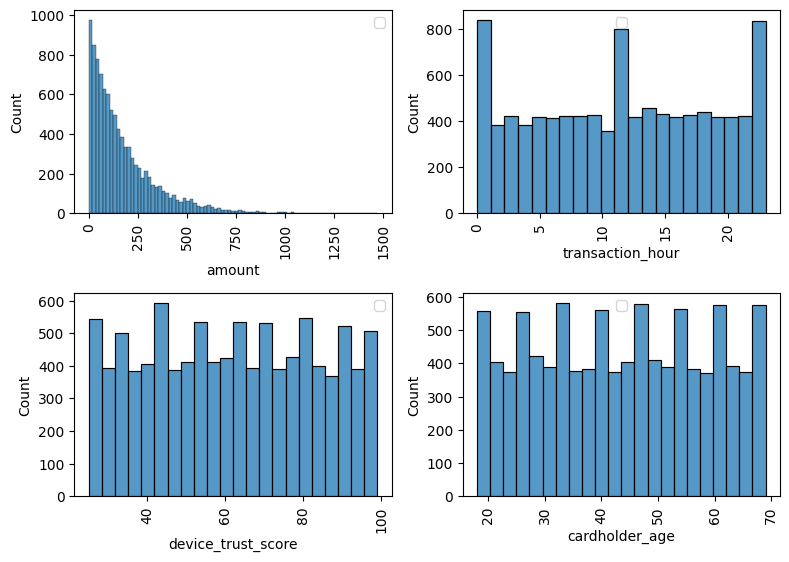

In [54]:
plt.figure(figsize=(8,8))
for index,col in enumerate(num,1):
    plt.subplot(3,2,index)
    sns.histplot(data=df[col],palette='Set2')
    plt.xlabel(col)
    plt.legend()
    plt.xticks(rotation=90)
plt.tight_layout()



## Categorical Feature Analysis Report

The dataset contains several categorical and discrete features that provide useful insights into transaction behavior. The `merchant_category` feature consists of five categories: Food, Clothing, Travel, Grocery, and Electronics. The distribution is fairly balanced, with each category contributing approximately 19–21% of the total transactions. Food accounts for the highest proportion (20.93%), while Electronics has the lowest (19.23%). This balanced distribution indicates that no single merchant category dominates the dataset.

The `foreign_transaction` feature shows that most transactions (90.22%) are domestic, while only 9.78% are foreign transactions. Similarly, the `location_mismatch` feature reveals that 91.43% of transactions occur from expected locations, whereas only 8.57% show a mismatch between the transaction location and the cardholder's usual location. These relatively rare events may serve as important indicators of suspicious or fraudulent activity.

The `velocity_last_24h` feature represents the number of transactions performed by a cardholder within the previous 24 hours. Most users perform one or two transactions per day, accounting for 26.94% and 26.62% of the data
set, respectively. The frequency gradually decreases as the number of daily transactions increases, with only a very small percentage of users making more than six transactions within a day. High transaction velocity may indicate unusual spending behavior and could be a valuable feature for fraud detection.

The target variable, `is_fraud`, is highly imbalanced. Out of 10,000 transactions, 9,849 (98.49%) are legitimate, while only 151 (1.51%) are fraudulent. This significant class imbalance is a common characteristic of fraud detection datasets and should be considered during model development. Appropriate evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC, along with techniques like class weighting or resampling, may be necessary to effectively identify fraudulent transactions.

Overall, the categorical feature analysis indicates that the dataset is well distributed across merchant categories, while foreign transactions, location mismatches, high transaction velocity, and the severely imbalanced target variable provide valuable information for building an effective credit card fraud detection model.


## Numerical Feature Analysis Report 



The numerical features were analyzed using histograms to understand their distributions and identify any noticeable patterns.

The **`amount`** feature exhibits a highly right-skewed distribution. Most transactions involve relatively small amounts, while only a few transactions have very high values, extending up to approximately 1500. This indicates the presence of outliers and suggests that the feature may benefit from scaling or transformation before model training.

The **`transaction_hour`** feature is distributed across all 24 hours of the day. Transactions occur throughout the day with no extreme concentration in a particular time period, although slight variations are observed during certain hours. This suggests that transactions are recorded continuously over the entire day.

The **`device_trust_score`** feature is reasonably well distributed across its range (approximately 20–100). No severe skewness or abnormal concentration is observed, indicating that the dataset contains transactions from devices with varying levels of trust.

Similarly, the **`cardholder_age`** feature shows a fairly uniform distribution between approximately 18 and 70 years of age. There are no significant outliers or unusual age concentrations, suggesting that the dataset includes cardholders from a broad range of age groups.

Overall, the numerical features appear suitable for machine learning. While most variables exhibit balanced distributions, the `amount` feature is positively skewed and contains high-value outliers. Appropriate preprocessing techniques such as feature scaling and outlier-aware modeling should be considered to improve model performance.


In [55]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [56]:
#.) When the Fraud has happened ,what was that amount?
df[df["is_fraud"]==1]['amount'].median()

np.float64(118.94)

In [57]:
#change into time 
df["transaction_hour"] =(
    pd.to_datetime(df["transaction_hour"], format="%H")
      .dt.strftime("%I:%M %p")
)

In [58]:
# Time when most fraud cases has happend?

df[df["is_fraud"]==1]['transaction_hour'].value_counts(normalize=True)*100

transaction_hour
12:00 AM    24.503311
01:00 AM    22.516556
03:00 AM    17.880795
02:00 AM    15.231788
07:00 PM     2.649007
08:00 AM     1.986755
11:00 PM     1.986755
11:00 AM     1.324503
03:00 PM     1.324503
06:00 AM     1.324503
01:00 PM     1.324503
05:00 AM     1.324503
05:00 PM     1.324503
08:00 PM     1.324503
09:00 AM     0.662252
09:00 PM     0.662252
06:00 PM     0.662252
04:00 AM     0.662252
02:00 PM     0.662252
10:00 AM     0.662252
Name: proportion, dtype: float64

Multivariate Analysis

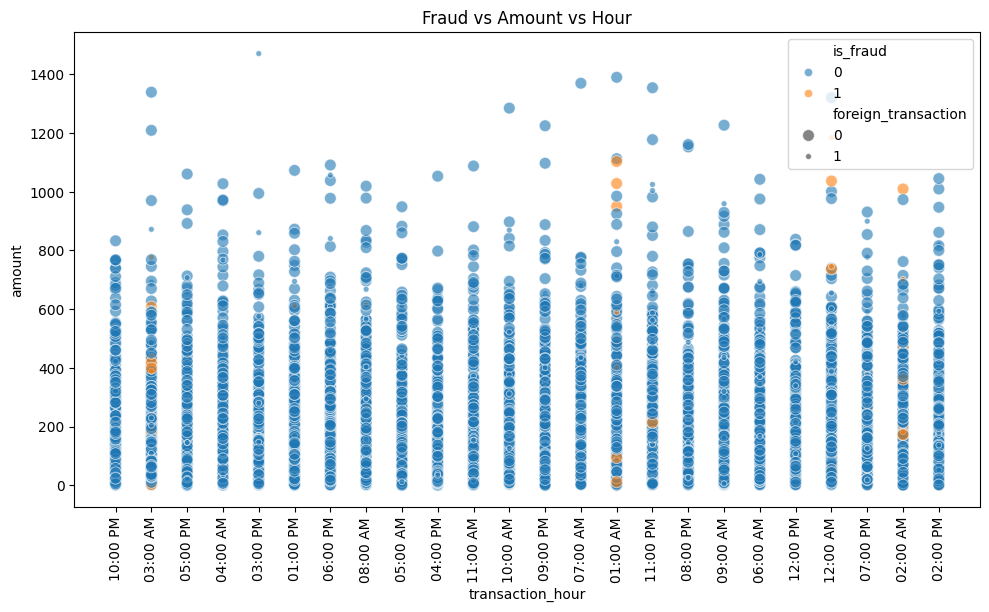

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='transaction_hour',
    y='amount',
    hue='is_fraud',
    size='foreign_transaction',
    alpha=0.6
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.title("Fraud vs Amount vs Hour")
plt.show()

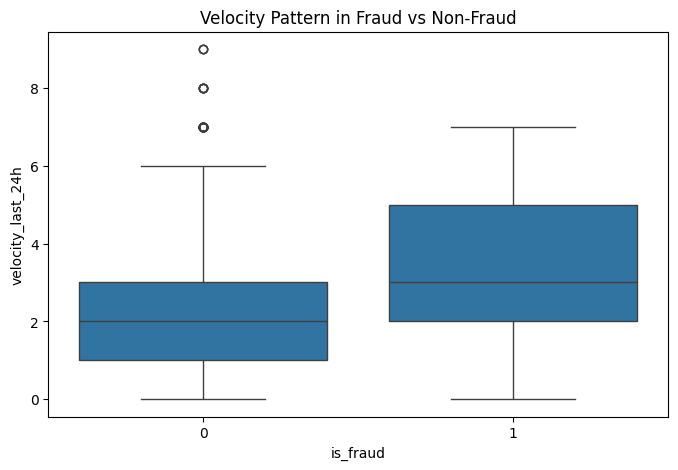

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='velocity_last_24h'
)

plt.title("Velocity Pattern in Fraud vs Non-Fraud")
plt.show()

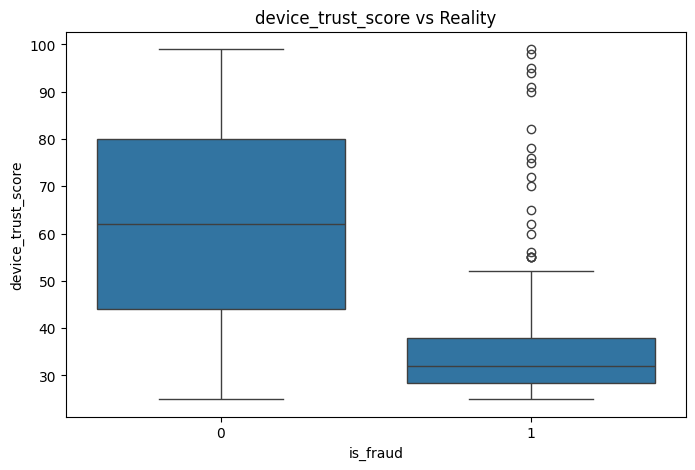

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='device_trust_score'
)

plt.title("device_trust_score vs Reality")
plt.show()

<Axes: xlabel='is_fraud', ylabel='count'>

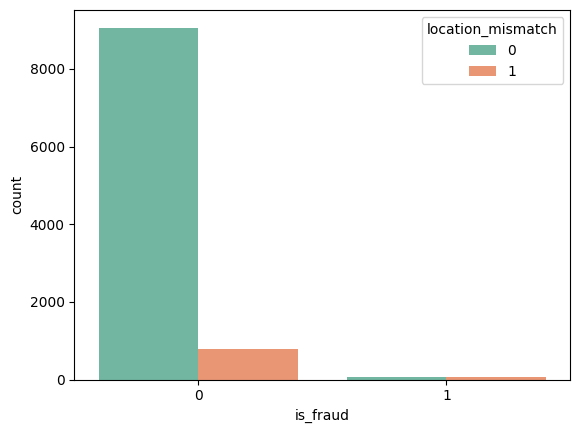

In [66]:
sns.countplot(data=df,x=df['is_fraud'],hue=df['location_mismatch'],palette="Set2")

ANSWERS OF THAT QUESTIONS:


1.) When the Fraud has happened ,what was that amount?


Analysis:

Compare fraud vs non-fraud transaction amounts.

📌 Key Insight:
Fraud occurs across both low and high amounts

No fixed pattern like “only high amount fraud”

Some fraud cases appear as small test transactions, others as large-value attacks

📌 Conclusion:

Transaction amount alone is not a strong predictor of fraud, but contributes to risk when combined with other features.



2.) Time when most fraud cases has happend?

Insight:

Fraud cases are analyzed across transaction_hour.

📌 Key Pattern:
Higher fraud frequency during late night and early morning hours (approx. 00:00–03:00)

Lower fraud activity during peak business hours

📌 Conclusion:

Fraud tends to increase during off-peak monitoring hours when detection and user awareness are lower.

3.) Time when fraud happend + Amount + Foreign transcation

Multivariate Insight:

We analyze:

transaction hour

transaction amount

foreign transaction flag

 Key Observations:

Foreign transactions combined with odd hours show higher fraud likelihood

Fraudulent transactions often show:

higher variability in amount

clustering in specific time windows

stronger association with foreign flag = 1

📌 Conclusion:

Fraud is a multivariate behavior pattern, not dependent on a single feature.


4.) Does device trust score reflect real fraud behavior?

Fraud cases generally show lower device trust scores

However, overlap exists between fraud and non-fraud cases

 Conclusion:

Device trust score is a useful but not fully reliable standalone feature. It must be combined with behavioral signals like time, velocity, and transaction patterns.


5.)What is the age distribution of fraud users?

Observations:

Fraud is more common in:

younger users (20–35 years)

and occasionally older users (due to vulnerability factors)

📌 Conclusion:

Fraud activity is higher among digitally active age groups, especially young adults.


6.) when fraud has happened does location has mismatched ,from whwere they usually adhere

Fraud rate is compared between:

match vs mismatch transactions

📌 Observations:

If fraud rate is higher when mismatch = 1 → indicates risky behavior pattern

If difference is small → feature has weak predictive power